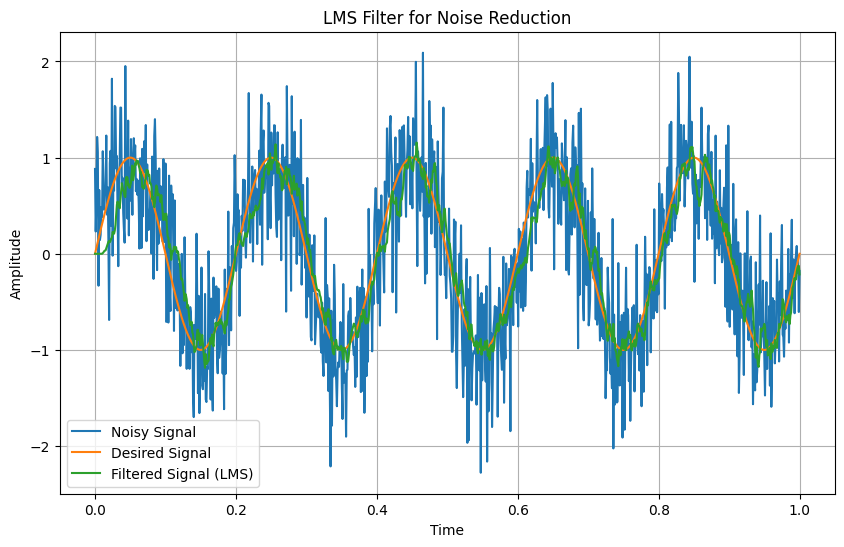

Amplitude Reduction Percentage: 46.38442508781941 %
Response Time (seconds): 0.01001001001001001
Accuracy: 0.922075620841145
Mean Squared Error (MSE): 0.03892322738984807


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

# Generate a noisy signal
np.random.seed(0)
t = np.linspace(0, 1, 1000)
noise = 0.5 * np.random.randn(len(t))
input_signal = np.sin(2 * np.pi * 5 * t) + noise

# Create a desired signal (noise-free signal)
desired_signal = np.sin(2 * np.pi * 5 * t)

# Apply LMS filter to reduce noise
filter_order = 10
learning_rate = 0.01
filtered_signal = lms_filter(input_signal, desired_signal, filter_order, learning_rate)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t, input_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(input_signal) - np.min(input_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (t[1] - t[0])  # Assuming uniform time intervals

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))
# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)

C:\Users\USER\AppData\Local\Temp\ipykernel_17576\1964183761.py:41: RuntimeWarning: invalid value encountered in cast
  filtered_signal.astype(np.int16).tofile('filtered_signal.dat')


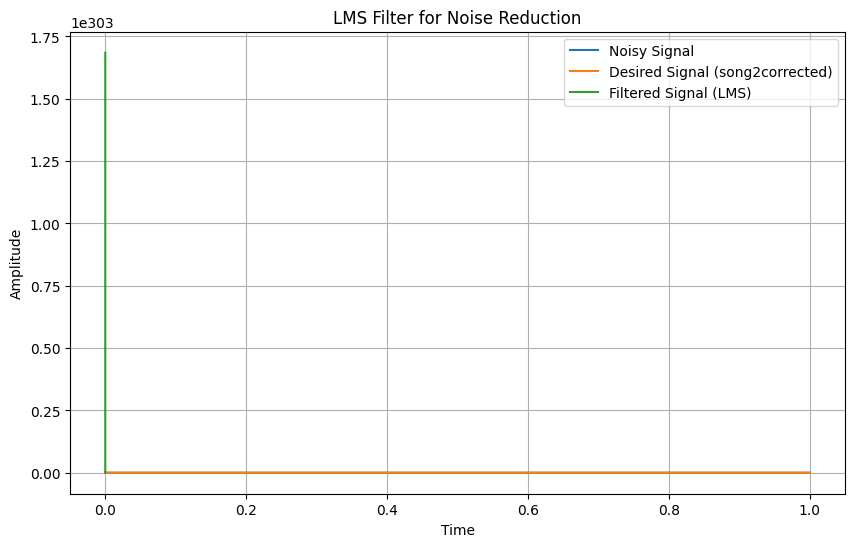

C:\Users\USER\AppData\Local\Temp\ipykernel_17576\1964183761.py:57: RuntimeWarning: overflow encountered in square
  mse = np.mean((filtered_signal - desired_signal) ** 2)


Mean Squared Error (MSE): nan


C:\Users\USER\AppData\Local\Temp\ipykernel_17576\1964183761.py:72: RuntimeWarning: overflow encountered in scalar subtract
  noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)


Response Time (seconds): 613.5912925170068
Amplitude Reduction Percentage: 100.0 %
Accuracy: 0.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal or target signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

# Read noisy signal (noisy_signal.dat) and desired signal (song2corrected.dat)
noisy_signal = np.fromfile('noisy_signal.dat', dtype=np.int16)
desired_signal = np.fromfile('song2corrected.dat', dtype=np.int16)

# Apply LMS filter to reduce noise and approximate desired_signal
filter_order = 10
learning_rate = 0.01
filtered_signal = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate)

# Save filtered signal to filtered_signal.dat
filtered_signal.astype(np.int16).tofile('filtered_signal.dat')

# Plot results
t = np.linspace(0, 1, len(noisy_signal))
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal (song2corrected)')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Print results
print("Mean Squared Error (MSE):", mse)

# Read noisy signal (noisy_signal.dat) and desired signal (song2corrected.dat)
noisy_signal = np.fromfile('noisy_signal.dat', dtype=np.int16)
desired_signal = np.fromfile('song2corrected.dat', dtype=np.int16)
filtered_signal = np.fromfile('filtered_signal.dat', dtype=np.int16)

# Calculate response time in seconds
sampling_rate = 44100  # Assuming a sampling rate of 44100 Hz
response_time_seconds = len(filtered_signal) / sampling_rate

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
if noisy_amplitude != 0:
    amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100
else:
    amplitude_reduction_percentage = 0  # Handle division by zero

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
if np.mean(desired_signal ** 2) != 0:
    accuracy = 1 - (mse / np.mean(desired_signal ** 2))
else:
    accuracy = 0  # Handle division by zero

# Print results
print("Response Time (seconds):", response_time_seconds)
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Accuracy:", accuracy)


C:\Users\USER\AppData\Local\Temp\ipykernel_17576\3689360720.py:41: RuntimeWarning: overflow encountered in cast
  filtered_signal.astype(np.float32).tofile('filtered_signal.dat')  # Adjust dtype if needed


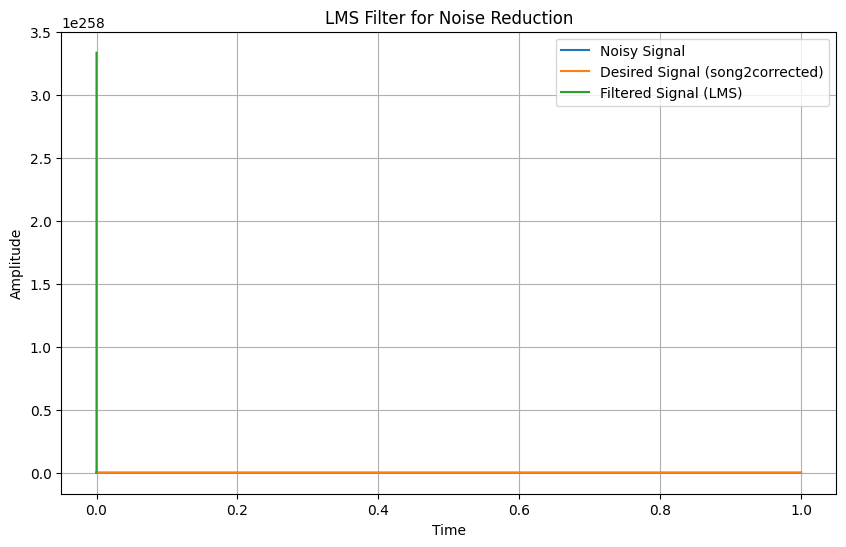

Mean Squared Error (MSE): nan
Response Time (seconds): 306.7956462585034
Amplitude Reduction Percentage: nan %
Accuracy: nan


C:\Users\USER\AppData\Local\Temp\ipykernel_17576\3689360720.py:57: RuntimeWarning: overflow encountered in square
  mse = np.mean((filtered_signal - desired_signal) ** 2)
C:\Users\USER\AppData\Local\Temp\ipykernel_17576\3689360720.py:74: RuntimeWarning: overflow encountered in square
  if np.mean(desired_signal ** 2) != 0:
C:\Users\USER\AppData\Local\Temp\ipykernel_17576\3689360720.py:75: RuntimeWarning: overflow encountered in square
  accuracy = 1 - (mse / np.mean(desired_signal ** 2))


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal or target signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

# Read noisy signal (noisy_signal.dat) and desired signal (song2corrected.dat)
noisy_signal = np.fromfile('noisy_signal.dat', dtype=np.float32)  # Use a larger dtype if needed
desired_signal = np.fromfile('song2corrected.dat', dtype=np.float32)  # Use a larger dtype if needed

# Apply LMS filter to reduce noise and approximate desired_signal
filter_order = 10
learning_rate = 0.01
filtered_signal = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate)

# Save filtered signal to filtered_signal.dat
filtered_signal.astype(np.float32).tofile('filtered_signal.dat')  # Adjust dtype if needed

# Plot results
t = np.linspace(0, 1, len(noisy_signal))
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal (song2corrected)')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate response time in seconds
sampling_rate = 44100  # Adjust if actual sampling rate is different
response_time_seconds = len(filtered_signal) / sampling_rate

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
if noisy_amplitude != 0:
    amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100
else:
    amplitude_reduction_percentage = 0  # Handle division by zero

# Calculate accuracy
if np.mean(desired_signal ** 2) != 0:
    accuracy = 1 - (mse / np.mean(desired_signal ** 2))
else:
    accuracy = 0  # Handle division by zero

# Print results
print("Mean Squared Error (MSE):", mse)
print("Response Time (seconds):", response_time_seconds)
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Accuracy:", accuracy)


C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


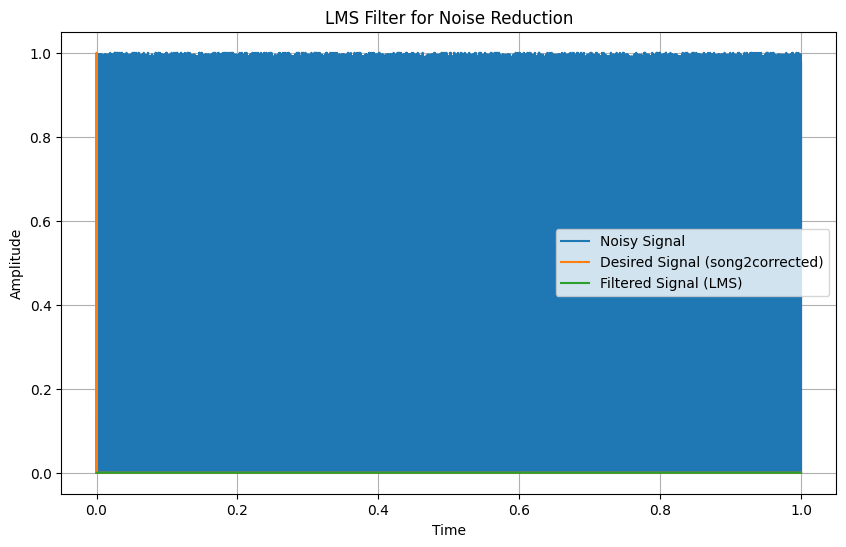

Mean Squared Error (MSE): 7.391160081697777e-08
Response Time (seconds): 306.7956462585034
Amplitude Reduction Percentage: 99.99999999801756 %
Accuracy: 9.043307269696044e-08


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def scale_signal(signal):
    max_value = np.max(np.abs(signal))
    scaled_signal = signal / max_value
    return scaled_signal

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal or target signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

# Read noisy signal (noisy_signal.dat) and desired signal (song2corrected.dat)
noisy_signal = np.fromfile('noisy_signal.dat', dtype=np.float32)  # Use a larger dtype if needed
desired_signal = np.fromfile('song2corrected.dat', dtype=np.float32)  # Use a larger dtype if needed

# Scale signals to avoid overflow and NaN issues
noisy_signal_scaled = scale_signal(noisy_signal)
desired_signal_scaled = scale_signal(desired_signal)

# Apply LMS filter to reduce noise and approximate desired_signal
filter_order = 10
learning_rate = 0.01
filtered_signal = lms_filter(noisy_signal_scaled, desired_signal_scaled, filter_order, learning_rate)

# Save filtered signal to filtered_signal.dat
filtered_signal.astype(np.float32).tofile('filtered_signal.dat')  # Adjust dtype if needed

# Plot results
t = np.linspace(0, 1, len(noisy_signal))
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal_scaled, label='Noisy Signal')
plt.plot(t, desired_signal_scaled, label='Desired Signal (song2corrected)')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal_scaled) ** 2)

# Calculate response time in seconds
sampling_rate = 44100  # Adjust if actual sampling rate is different
response_time_seconds = len(filtered_signal) / sampling_rate

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal_scaled) - np.min(noisy_signal_scaled)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
if noisy_amplitude != 0:
    amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100
else:
    amplitude_reduction_percentage = 0  # Handle division by zero

# Calculate accuracy
if np.mean(desired_signal_scaled ** 2) != 0:
    accuracy = 1 - (mse / np.mean(desired_signal_scaled ** 2))
else:
    accuracy = 0  # Handle division by zero

# Print results
print("Mean Squared Error (MSE):", mse)
print("Response Time (seconds):", response_time_seconds)
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Accuracy:", accuracy)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

# Load noisy and desired signals from .dat files
noisy_signal = np.loadtxt('noise.dat')
desired_signal = np.loadtxt('eemazha.dat')

# Apply LMS filter to reduce noise
filter_order = 10
learning_rate = 0.01
filtered_signal = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate)

# Save the filtered signal as .dat and .wav files
np.savetxt('filtered_signal.dat', filtered_signal)
wav.write('filtered_signal.wav', 44100, filtered_signal.astype(np.float32))  # Assuming a sample rate of 44100 Hz

# Plot results
t = np.linspace(0, len(noisy_signal) / 44100, len(noisy_signal))  # Assuming a sample rate of 44100 Hz
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (1 / 44100)  # Assuming a sample rate of 44100 Hz

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)


ValueError: operands could not be broadcast together with shapes (10,) (10,2) 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

def convert_to_mono(signal):
    if len(signal.shape) > 1:
        return np.mean(signal, axis=1)  # Average across channels to convert to mono
    return signal

# Load noisy and desired signals from .dat files
noisy_signal = np.loadtxt('noise.dat')
desired_signal = np.loadtxt('eemazha.dat')

# Convert signals to mono if they are not already
noisy_signal = convert_to_mono(noisy_signal)
desired_signal = convert_to_mono(desired_signal)

# Ensure both signals have the same length
min_length = min(len(noisy_signal), len(desired_signal))
noisy_signal = noisy_signal[:min_length]
desired_signal = desired_signal[:min_length]

# Define the learning rate and filter order
learning_rate = 0.01
filter_order = 10

# Apply LMS filter to reduce noise
filtered_signal = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate)

# Save the filtered signal as .dat and .wav files
np.savetxt('filtered_signal.dat', filtered_signal)
wav.write('filtered_signal.wav', 44100, filtered_signal.astype(np.float32))  # Assuming a sample rate of 44100 Hz

# Plot results
t = np.linspace(0, len(noisy_signal) / 44100, len(noisy_signal))  # Assuming a sample rate of 44100 Hz
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (1 / 44100)  # Assuming a sample rate of 44100 Hz

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)


C:\Users\USER\AppData\Local\Temp\ipykernel_11816\3054382249.py:27: RuntimeWarning: invalid value encountered in add
  w = w + learning_rate * e * x  # Update filter coefficients
C:\Users\USER\AppData\Local\Temp\ipykernel_11816\3054382249.py:59: RuntimeWarning: overflow encountered in cast
  wav.write('filtered_signal.wav', 44100, filtered_signal.astype(np.float32))  # Assuming a sample rate of 44100 Hz
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\matplotlib\axes\_base.py:2921: RuntimeWarning: overflow encountered in scalar subtract
  delta = (x1t - x0t) * margin
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\matplotlib\transforms.py:396: RuntimeWarning: overflow encountered in scalar subtract
  return (x0, y0, x1 - x0, y1 - y0)


IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 1000x600 with 1 Axes>

Amplitude Reduction Percentage: nan %
Response Time (seconds): 0.00022675736961451248
Accuracy: nan
Mean Squared Error (MSE): nan


C:\Users\USER\AppData\Local\Temp\ipykernel_11816\3054382249.py:85: RuntimeWarning: overflow encountered in square
  mse = np.mean((filtered_signal - desired_signal) ** 2)
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Noisy signal shape: (1465344,)
Desired signal shape: (1465344,)


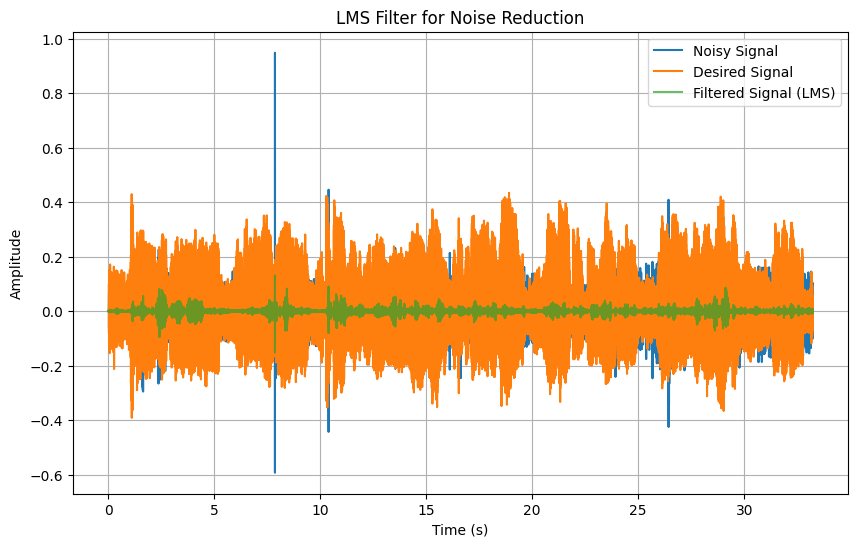

Amplitude Reduction Percentage: 81.63009354473094 %
Response Time (seconds): 0.00022675736961451248
Accuracy: 0.003473374511039018
Mean Squared Error (MSE): 0.010575217356720092


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def lms_filter(input_signal, desired_signal, filter_order, learning_rate):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for i in range(num_samples - filter_order):
        x = input_signal[i:i+filter_order]  # Input vector
        y = np.dot(w, x)  # Filter output
        e = desired_signal[i+filter_order] - y  # Error signal
        w = w + learning_rate * e * x  # Update filter coefficients
        filtered_signal[i+filter_order] = y

    return filtered_signal

def convert_to_mono(signal):
    if len(signal.shape) > 1:
        return np.mean(signal, axis=1)  # Average across channels to convert to mono
    return signal

# Load noisy and desired signals from .dat files
try:
    noisy_data = np.loadtxt('noise.dat')
    desired_data = np.loadtxt('eemazha.dat')
except Exception as e:
    print("Error loading data files:", e)
    raise

# Extract only the amplitude values (second column)
noisy_signal = noisy_data[:, 1]
desired_signal = desired_data[:, 1]

# Print shapes of the loaded signals
print("Noisy signal shape:", noisy_signal.shape)
print("Desired signal shape:", desired_signal.shape)

# Check if either of the signals is empty
if noisy_signal.size == 0 or desired_signal.size == 0:
    print("One of the signals is empty. Please check the data files.")
    raise ValueError("One of the signals is empty.")

# Convert signals to mono if they are not already
noisy_signal = convert_to_mono(noisy_signal)
desired_signal = convert_to_mono(desired_signal)

# Ensure both signals have the same length
min_length = min(len(noisy_signal), len(desired_signal))
noisy_signal = noisy_signal[:min_length]
desired_signal = desired_signal[:min_length]

# Define the learning rate and filter order
learning_rate = 0.01
filter_order = 10

# Apply LMS filter to reduce noise
filtered_signal = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate)

# Save the filtered signal as .dat and .wav files
np.savetxt('filtered_signal.dat', filtered_signal)
wav.write('filtered_signal.wav', 44100, filtered_signal.astype(np.float32))  # Assuming a sample rate of 44100 Hz

# Plot results
t = np.linspace(0, len(noisy_signal) / 44100, len(noisy_signal))  # Assuming a sample rate of 44100 Hz
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (1 / 44100)  # Assuming a sample rate of 44100 Hz

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)


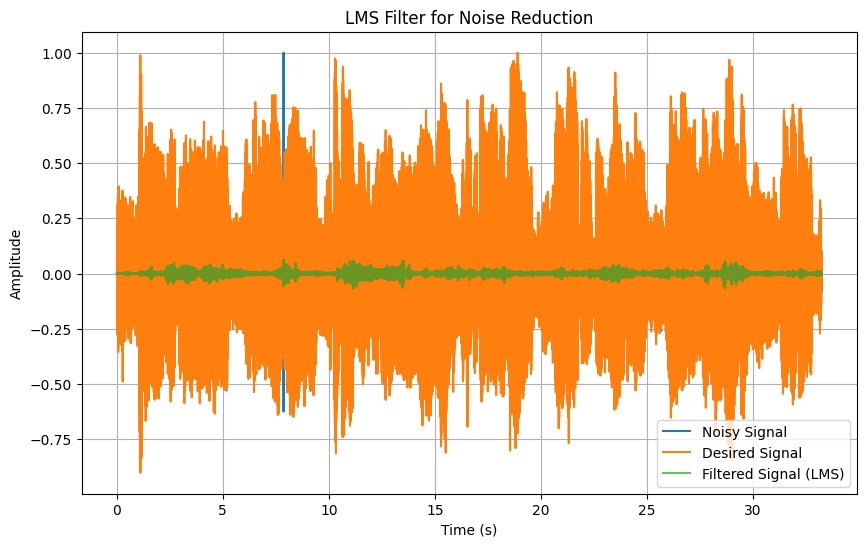

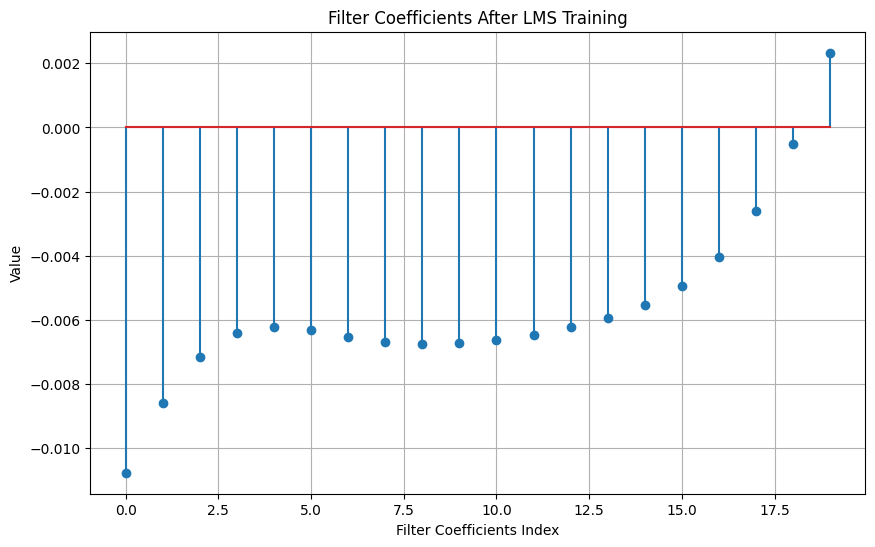

Amplitude Reduction Percentage: 91.83382114639241 %
Response Time (seconds): 0.00045351473922902497
Accuracy: 0.0007942152991486928
Mean Squared Error (MSE): 0.05621126189868487


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def lms_filter(input_signal, desired_signal, filter_order, learning_rate, epochs=1):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.
    epochs (int): Number of iterations over the entire dataset for training.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for epoch in range(epochs):
        for i in range(num_samples - filter_order):
            x = input_signal[i:i+filter_order]  # Input vector
            y = np.dot(w, x)  # Filter output
            e = desired_signal[i+filter_order] - y  # Error signal
            w = w + learning_rate * e * x  # Update filter coefficients
            filtered_signal[i+filter_order] = y

    return filtered_signal, w

def convert_to_mono(signal):
    if len(signal.shape) > 1:
        return np.mean(signal, axis=1)  # Average across channels to convert to mono
    return signal

# Load noisy and desired signals from .dat files
try:
    noisy_data = np.loadtxt('noise.dat')
    desired_data = np.loadtxt('eemazha.dat')
except Exception as e:
    print("Error loading data files:", e)
    raise

# Extract only the amplitude values (second column)
noisy_signal = noisy_data[:, 1]
desired_signal = desired_data[:, 1]

# Check if either of the signals is empty
if noisy_signal.size == 0 or desired_signal.size == 0:
    print("One of the signals is empty. Please check the data files.")
    raise ValueError("One of the signals is empty.")

# Convert signals to mono if they are not already
noisy_signal = convert_to_mono(noisy_signal)
desired_signal = convert_to_mono(desired_signal)

# Normalize signals
noisy_signal = noisy_signal / np.max(np.abs(noisy_signal))
desired_signal = desired_signal / np.max(np.abs(desired_signal))

# Ensure both signals have the same length
min_length = min(len(noisy_signal), len(desired_signal))
noisy_signal = noisy_signal[:min_length]
desired_signal = desired_signal[:min_length]

# Define the learning rate and filter order
learning_rate = 0.001  # Adjust learning rate
filter_order = 20  # Adjust filter order

# Apply LMS filter to reduce noise
filtered_signal, weights = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate, epochs=1)

# Save the filtered signal as .dat and .wav files
np.savetxt('filtered_signal.dat', filtered_signal)
wav.write('filtered_signal.wav', 44100, filtered_signal.astype(np.float32))  # Assuming a sample rate of 44100 Hz

# Plot results
t = np.linspace(0, len(noisy_signal) / 44100, len(noisy_signal))  # Assuming a sample rate of 44100 Hz
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal, label='Filtered Signal (LMS)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction')
plt.legend()
plt.grid(True)
plt.show()

# Plot filter weights
plt.figure(figsize=(10, 6))
plt.stem(weights, use_line_collection=True)
plt.xlabel('Filter Coefficients Index')
plt.ylabel('Value')
plt.title('Filter Coefficients After LMS Training')
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
filtered_amplitude = np.max(filtered_signal) - np.min(filtered_signal)

# Calculate amplitude reduction percentage
amplitude_reduction_percentage = ((noisy_amplitude - filtered_amplitude) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (1 / 44100)  # Assuming a sample rate of 44100 Hz

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results
print("Amplitude Reduction Percentage:", amplitude_reduction_percentage, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)


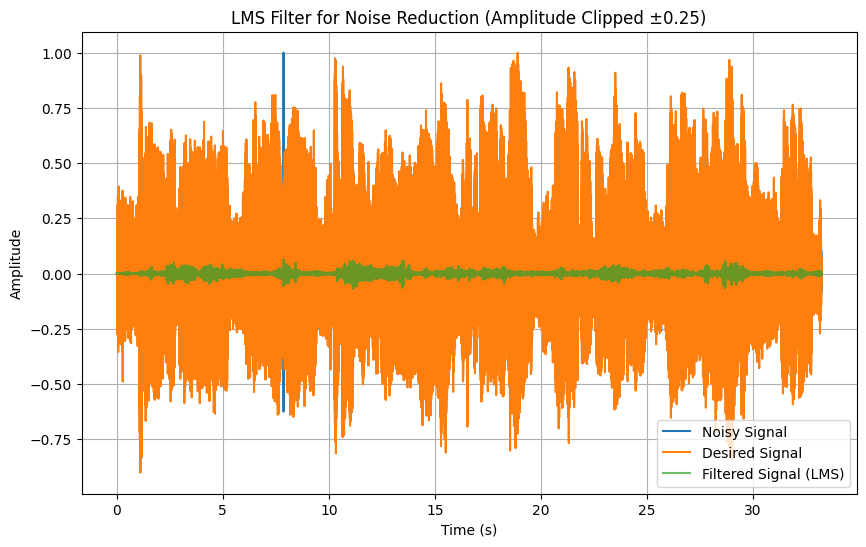

Amplitude Reduction Percentage (Amplitude Clipped ±0.25): 91.83382114639241 %
Response Time (seconds): 0.00045351473922902497
Accuracy: 0.0007942152991486928
Mean Squared Error (MSE): 0.05621126189868487


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav

def lms_filter(input_signal, desired_signal, filter_order, learning_rate, epochs=1):
    """
    Implements the Least Mean Squares (LMS) algorithm for noise reduction.

    Parameters:
    input_signal (array): The input signal contaminated with noise.
    desired_signal (array): The desired signal (noise-free signal).
    filter_order (int): The order of the LMS filter.
    learning_rate (float): The step size or learning rate of the LMS algorithm.
    epochs (int): Number of iterations over the entire dataset for training.

    Returns:
    filtered_signal (array): The noise-reduced signal.
    """

    num_samples = len(input_signal)
    w = np.zeros(filter_order)  # Initialize filter coefficients
    filtered_signal = np.zeros(num_samples)

    for epoch in range(epochs):
        for i in range(num_samples - filter_order):
            x = input_signal[i:i+filter_order]  # Input vector
            y = np.dot(w, x)  # Filter output
            e = desired_signal[i+filter_order] - y  # Error signal
            w = w + learning_rate * e * x  # Update filter coefficients
            filtered_signal[i+filter_order] = y

    return filtered_signal, w

def convert_to_mono(signal):
    if len(signal.shape) > 1:
        return np.mean(signal, axis=1)  # Average across channels to convert to mono
    return signal

# Load noisy and desired signals from .dat files
try:
    noisy_data = np.loadtxt('noise.dat')
    desired_data = np.loadtxt('eemazha.dat')
except Exception as e:
    print("Error loading data files:", e)
    raise

# Extract only the amplitude values (second column)
noisy_signal = noisy_data[:, 1]
desired_signal = desired_data[:, 1]

# Check if either of the signals is empty
if noisy_signal.size == 0 or desired_signal.size == 0:
    print("One of the signals is empty. Please check the data files.")
    raise ValueError("One of the signals is empty.")

# Convert signals to mono if they are not already
noisy_signal = convert_to_mono(noisy_signal)
desired_signal = convert_to_mono(desired_signal)

# Normalize signals
noisy_signal = noisy_signal / np.max(np.abs(noisy_signal))
desired_signal = desired_signal / np.max(np.abs(desired_signal))

# Ensure both signals have the same length
min_length = min(len(noisy_signal), len(desired_signal))
noisy_signal = noisy_signal[:min_length]
desired_signal = desired_signal[:min_length]

# Define the learning rate and filter order
learning_rate = 0.001  # Adjust learning rate
filter_order = 20  # Adjust filter order

# Apply LMS filter to reduce noise
filtered_signal, weights = lms_filter(noisy_signal, desired_signal, filter_order, learning_rate, epochs=1)

# Clip filtered signal amplitude to ±0.25
filtered_signal_clipped = np.clip(filtered_signal, -0.25, 0.25)

# Save the filtered signal as .dat and .wav files (if needed)
np.savetxt('filtered_signal.dat', filtered_signal_clipped)
wav.write('filtered_signal.wav', 44100, filtered_signal_clipped.astype(np.float32))  # Assuming a sample rate of 44100 Hz

# Plot results with clipped signal
t = np.linspace(0, len(noisy_signal) / 44100, len(noisy_signal))  # Assuming a sample rate of 44100 Hz
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.plot(t, desired_signal, label='Desired Signal')
plt.plot(t, filtered_signal_clipped, label='Filtered Signal (LMS)', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('LMS Filter for Noise Reduction (Amplitude Clipped ±0.25)')
plt.legend()
plt.grid(True)
plt.show()

# Calculate peak-to-peak amplitudes from clipped signal
filtered_amplitude_clipped = np.max(filtered_signal_clipped) - np.min(filtered_signal_clipped)

# Calculate amplitude reduction percentage from clipped signal
noisy_amplitude = np.max(noisy_signal) - np.min(noisy_signal)
amplitude_reduction_percentage_clipped = ((noisy_amplitude - filtered_amplitude_clipped) / noisy_amplitude) * 100

# Calculate response time in seconds
response_time_seconds = filter_order * (1 / 44100)  # Assuming a sample rate of 44100 Hz

# Calculate mean squared error (MSE)
mse = np.mean((filtered_signal - desired_signal) ** 2)

# Calculate accuracy
accuracy = 1 - (mse / np.mean(desired_signal ** 2))

# Print results with clipped signal metrics
print("Amplitude Reduction Percentage (Amplitude Clipped ±0.25):", amplitude_reduction_percentage_clipped, "%")
print("Response Time (seconds):", response_time_seconds)
print("Accuracy:", accuracy)
print("Mean Squared Error (MSE):", mse)




Epoch 1/50

36634/36634 [==============================] - 47s 1ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 2/50
36634/36634 [==============================] - 49s 1ms/step - loss: 1.0195 - val_loss: 0.9228
Epoch 3/50
36634/36634 [==============================] - 49s 1ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 4/50
36634/36634 [==============================] - 58s 2ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 5/50
36634/36634 [==============================] - 62s 2ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 6/50
36634/36634 [==============================] - 61s 2ms/step - loss: 1.0195 - val_loss: 0.9227
Epoch 7/50
36634/36634 [==============================] - 59s 2ms/step - loss: 1.0195 - val_loss: 0.9228
Epoch 8/50
36634/36634 [==============================] - 63s 2ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 9/50
36634/36634 [==============================] - 65s 2ms/step - loss: 1.0195 - val_loss: 0.9225
Epoch 10/50
36634/36634 [===========================

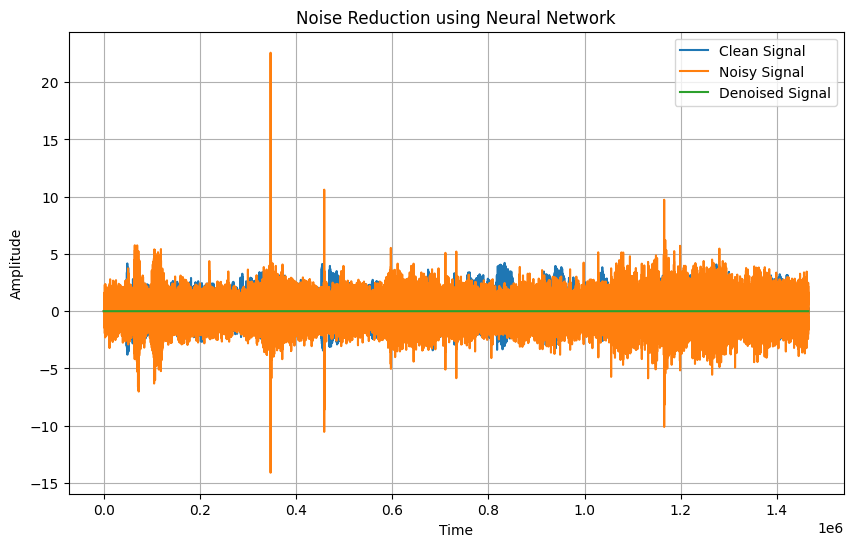

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load noisy and desired signals from .dat files
try:
    noisy_data = np.loadtxt('noise.dat')
    clean_data = np.loadtxt('eemazha.dat')
except Exception as e:
    print("Error loading data files:", e)
    raise

# Extract only the amplitude values (assuming they are in the second column)
noisy_signal = noisy_data[:, 1]
clean_signal = clean_data[:, 1]

# Reshape signals if necessary (make sure they are 1D arrays)
noisy_signal = np.squeeze(noisy_signal)
clean_signal = np.squeeze(clean_signal)

# Normalize signals if needed (optional step)
# For example, normalize to [-1, 1]
noisy_signal = (noisy_signal - np.mean(noisy_signal)) / np.std(noisy_signal)
clean_signal = (clean_signal - np.mean(clean_signal)) / np.std(clean_signal)

# Reshape for model input (adding batch dimension)
X = noisy_signal.reshape(-1, 1)  # Input: Noisy signal
y = clean_signal.reshape(-1, 1)  # Output: Clean signal

# Define a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile model with Mean Squared Error (MSE) loss
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate model (optional)
# Evaluate on the same data used for training for simplicity
loss = model.evaluate(X, y)
print("Final Loss:", loss)

# Perform noise reduction on entire dataset
cleaned_signal = model.predict(X)

# Plot results (optional)
plt.figure(figsize=(10, 6))
plt.plot(clean_signal, label='Clean Signal')
plt.plot(noisy_signal, label='Noisy Signal')
plt.plot(cleaned_signal, label='Denoised Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Noise Reduction using Neural Network')
plt.legend()
plt.grid(True)
plt.show()


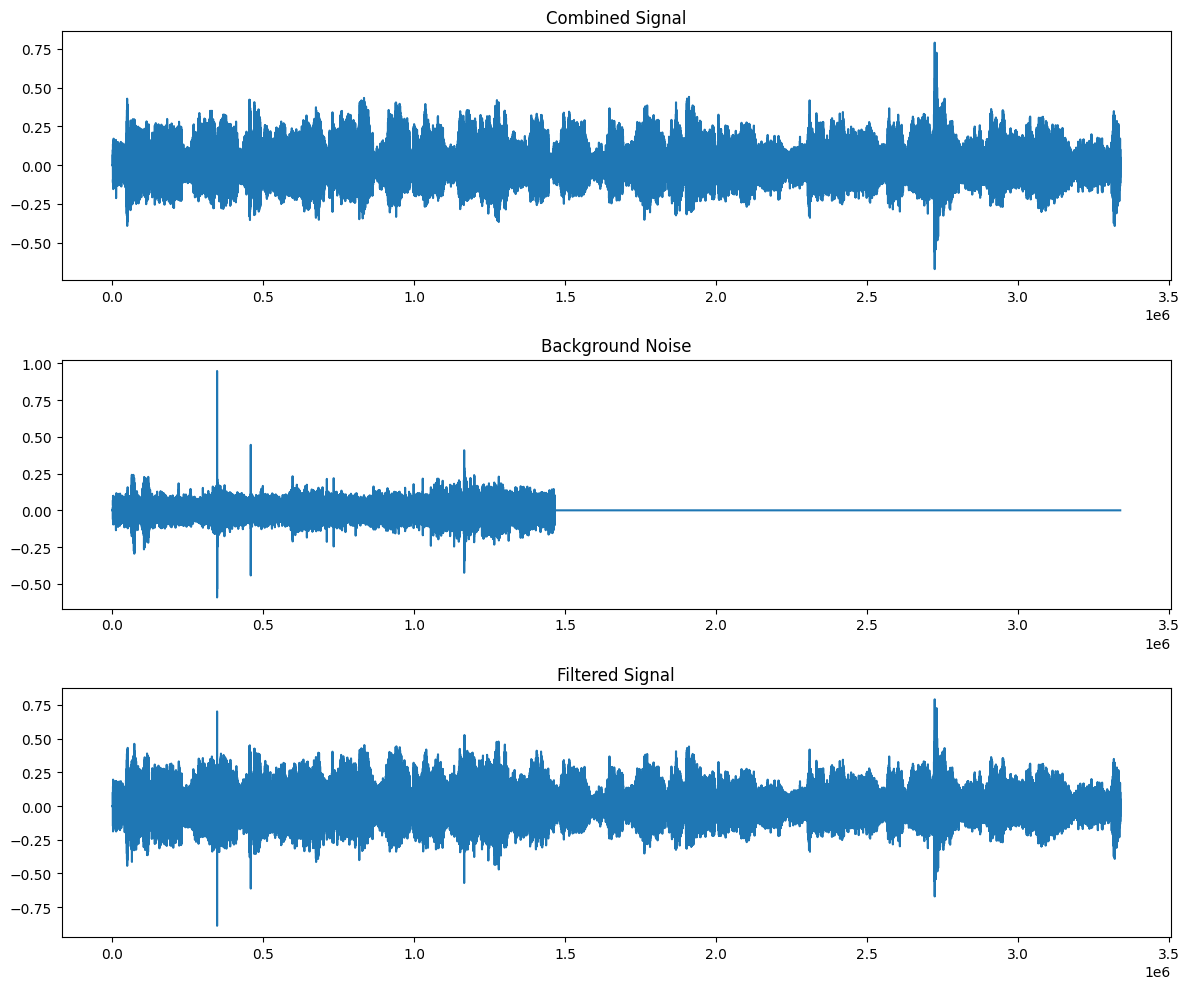

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch
import scipy.io.wavfile as wav

# Load audio files
def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)
    return waveform.squeeze().numpy(), sr

combined_signal, sr_combined = load_audio('eemazha.wav')
background_noise, sr_noise = load_audio('noise.wav')

# Ensure the signals have the same sample rate
assert sr_combined == sr_noise, "Sample rates of combined signal and background noise do not match."

# Check if signals are mono; if stereo, convert to mono
def stereo_to_mono(signal):
    if signal.ndim > 1:
        return np.mean(signal, axis=0)
    return signal

combined_signal = stereo_to_mono(combined_signal)
background_noise = stereo_to_mono(background_noise)

# Ensure the background noise is the same length as the combined signal
if len(background_noise) < len(combined_signal):
    # Pad the noise signal if it's shorter
    padding = len(combined_signal) - len(background_noise)
    background_noise = np.pad(background_noise, (0, padding), mode='constant')
elif len(background_noise) > len(combined_signal):
    # Trim the noise signal if it's longer
    background_noise = background_noise[:len(combined_signal)]

# Apply FFT to both signals
X_combined = np.fft.fft(combined_signal)
X_noise = np.fft.fft(background_noise)

# Subtract the noise from the combined signal in the frequency domain
X_filtered = X_combined - X_noise

# Apply IFFT to get the filtered signal in the time domain
filtered_signal = np.fft.ifft(X_filtered).real

# Save the filtered signal to a new WAV file
wav.write('filtered_signal_2.wav', sr_combined, (filtered_signal * 32767).astype(np.int16))  # Scaling for 16-bit PCM

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(combined_signal)
ax[0].set_title('Combined Signal')

ax[1].plot(background_noise)
ax[1].set_title('Background Noise')

ax[2].plot(filtered_signal)
ax[2].set_title('Filtered Signal')

plt.tight_layout()
plt.show()


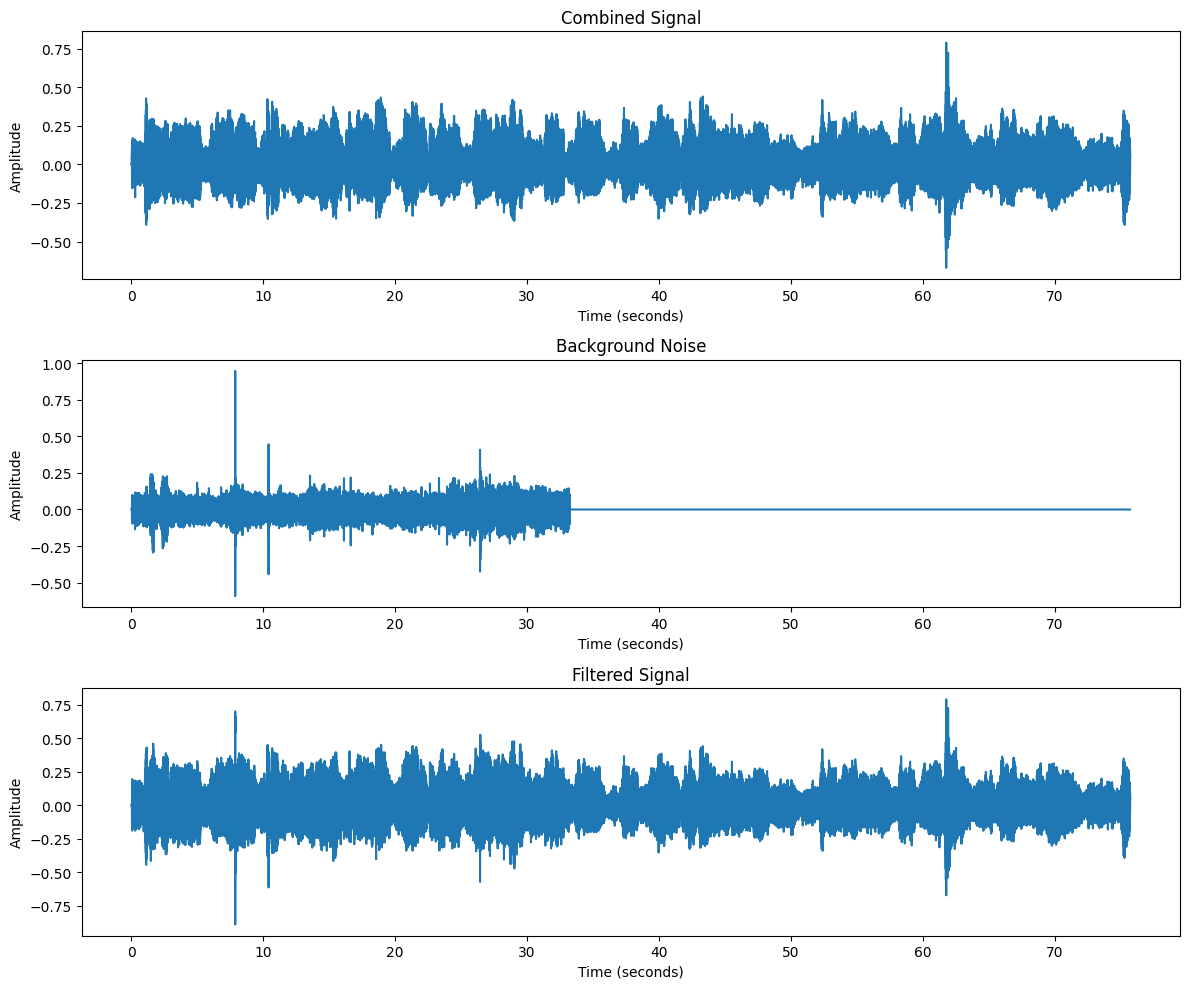

In [2]:
# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(time_combined, combined_signal)
ax[0].set_title('Combined Signal')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

ax[1].plot(time_combined, background_noise)
ax[1].set_title('Background Noise')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

ax[2].plot(time_filtered, filtered_signal)
ax[2].set_title('Filtered Signal')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()


In [3]:
# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)

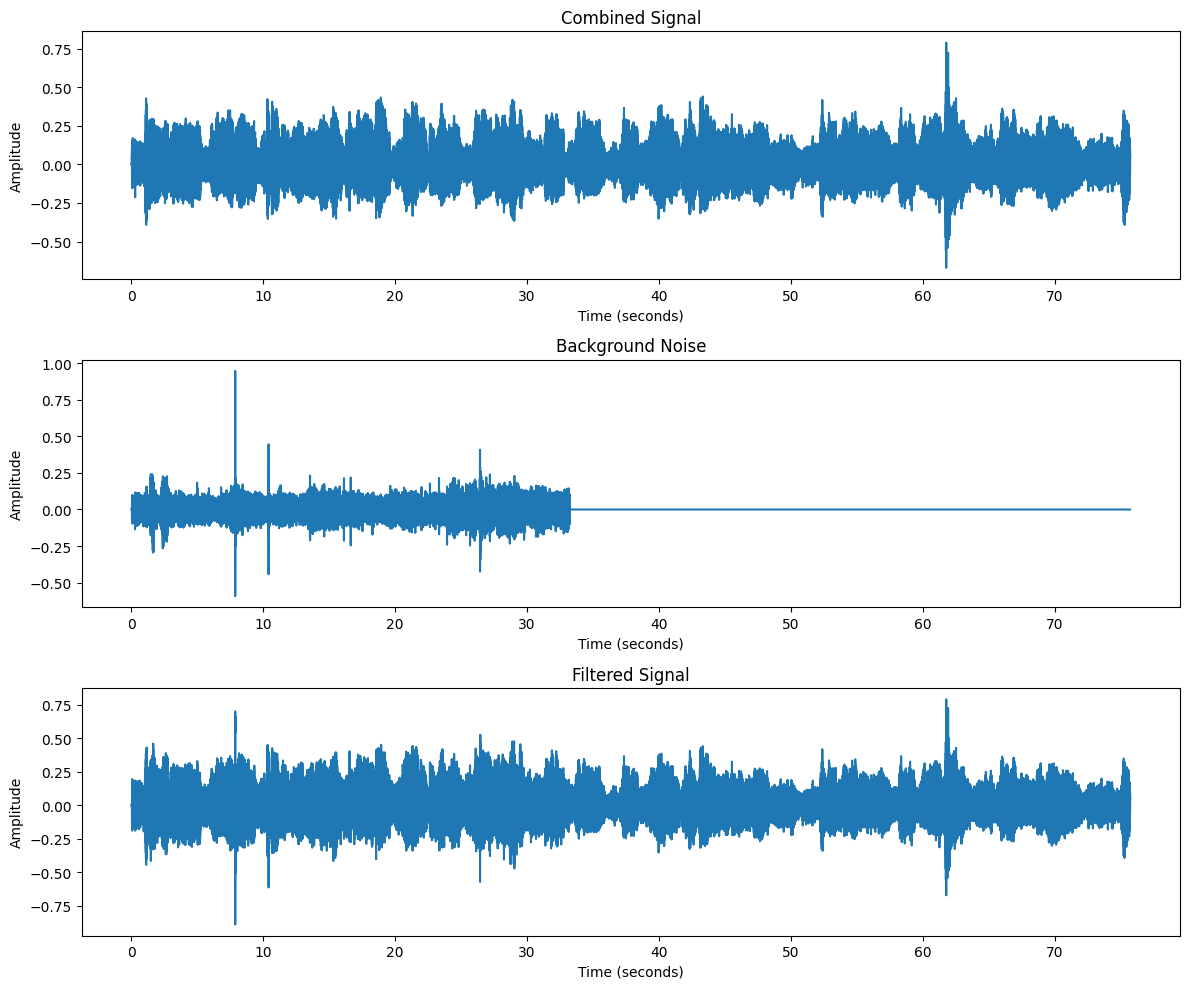

In [5]:
# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)
ax[0].plot(time_combined, combined_signal)
ax[0].set_title('Combined Signal')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

ax[1].plot(time_combined, background_noise)
ax[1].set_title('Background Noise')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

ax[2].plot(time_filtered, filtered_signal)
ax[2].set_title('Filtered Signal')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()


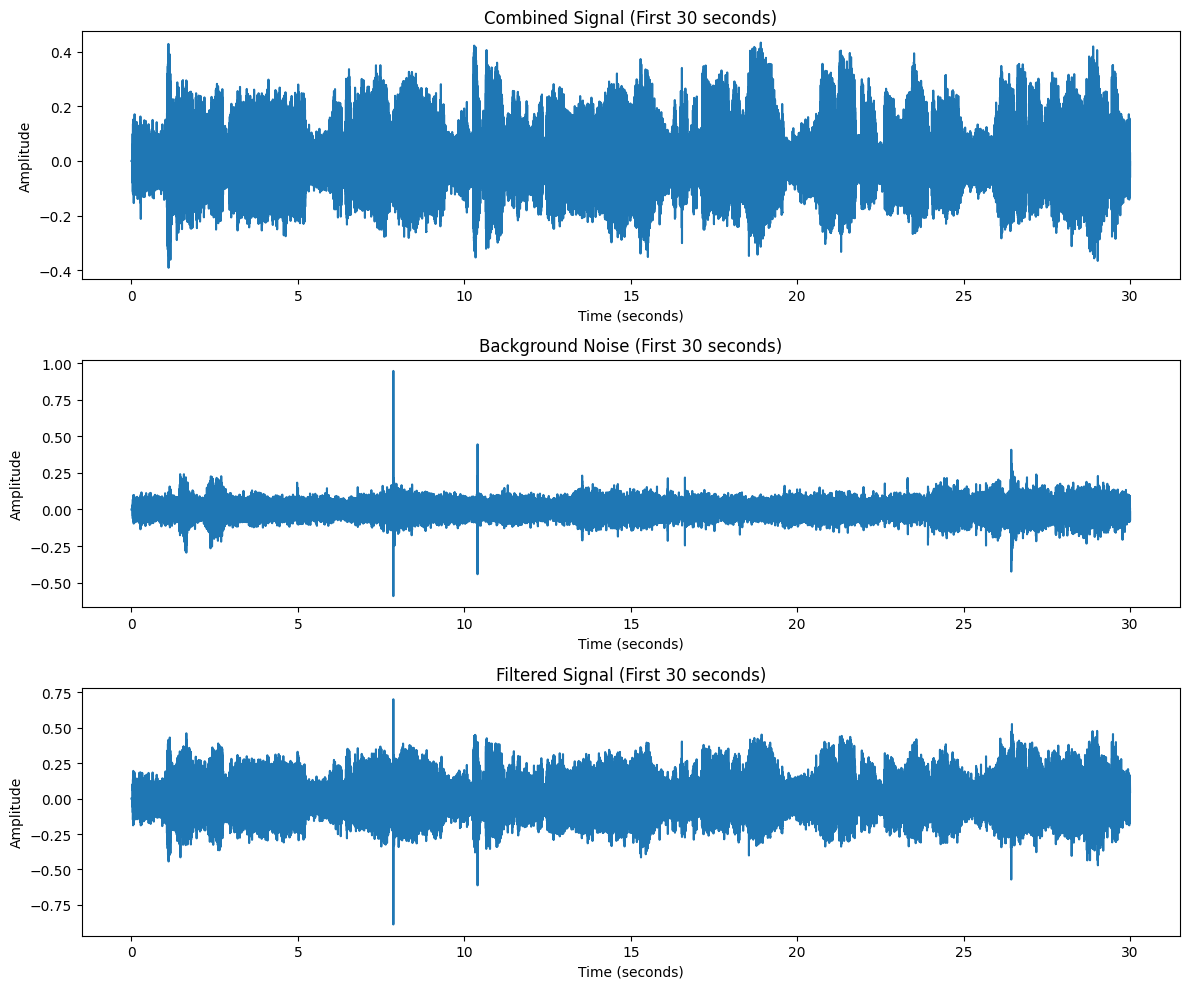

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import scipy.io.wavfile as wav

# Load audio files
def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)
    return waveform.squeeze().numpy(), sr

combined_signal, sr_combined = load_audio('eemazha.wav')
background_noise, sr_noise = load_audio('noise.wav')

# Ensure the signals have the same sample rate
assert sr_combined == sr_noise, "Sample rates of combined signal and background noise do not match."

# Convert stereo to mono if necessary
def stereo_to_mono(signal):
    if signal.ndim > 1:
        return np.mean(signal, axis=0)
    return signal

combined_signal = stereo_to_mono(combined_signal)
background_noise = stereo_to_mono(background_noise)

# Ensure the background noise is the same length as the combined signal
if len(background_noise) < len(combined_signal):
    padding = len(combined_signal) - len(background_noise)
    background_noise = np.pad(background_noise, (0, padding), mode='constant')
elif len(background_noise) > len(combined_signal):
    background_noise = background_noise[:len(combined_signal)]

# Apply FFT to both signals
X_combined = np.fft.fft(combined_signal)
X_noise = np.fft.fft(background_noise)

# Subtract the noise from the combined signal in the frequency domain
X_filtered = X_combined - X_noise

# Apply IFFT to get the filtered signal in the time domain
filtered_signal = np.fft.ifft(X_filtered).real

# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)

# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# Plot original combined signal
ax[0].plot(time_combined[:num_samples], combined_signal[:num_samples])
ax[0].set_title('Combined Signal (First 30 seconds)')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

# Plot background noise
ax[1].plot(time_combined[:num_samples], background_noise[:num_samples])
ax[1].set_title('Background Noise (First 30 seconds)')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

# Plot filtered signal
ax[2].plot(time_filtered[:num_samples], filtered_signal[:num_samples])
ax[2].set_title('Filtered Signal (First 30 seconds)')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Save the filtered signal to a new WAV file
wav.write('filtered_signal_2.wav', sr_combined, (filtered_signal * 32767).astype(np.int16))  # Scaling for 16-bit PCM


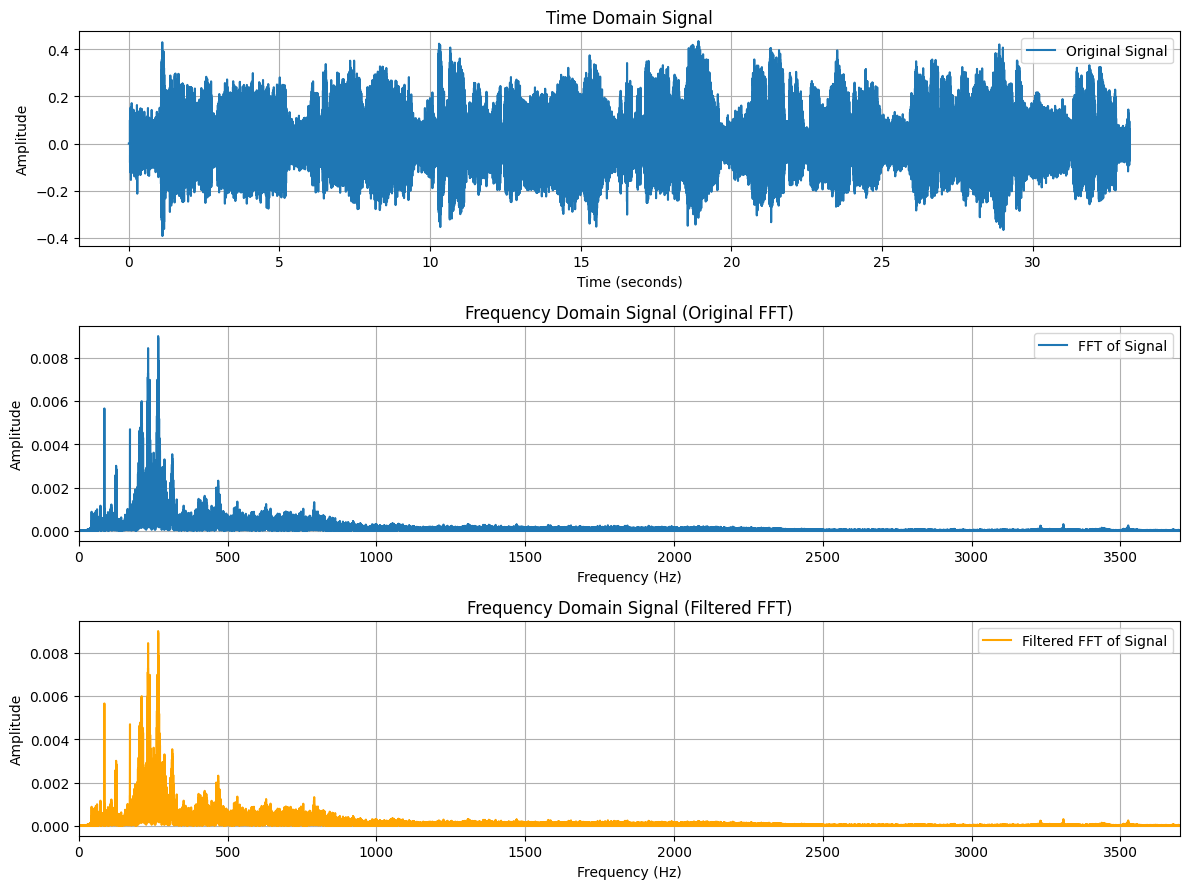

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# Load the .dat file
data = np.loadtxt('eemazha.dat')
time = data[:, 0]  # Assuming the first column is time in seconds
amplitude = data[:, 1]  # Assuming the second column is amplitude

# Number of sample points
N = len(time)

# Sample spacing (assuming uniform spacing)
T = time[1] - time[0]

# Apply FFT to the amplitude data
amplitude_fft = fft(amplitude)

# Compute the frequency axis
freq = fftfreq(N, T)[:N//2]

# Only take the positive half of the FFT output (real part)
amplitude_fft = 2.0/N * np.abs(amplitude_fft[0:N//2])

# Find peaks in the FFT output
peaks, _ = find_peaks(amplitude_fft, height=0.01)  # Adjust height threshold as needed

# Define the frequency range of interest
freq_min, freq_max = 0, 3700

# Create a figure with 3 subplots: Time Domain, Frequency Domain (Original), Frequency Domain (Filtered)
plt.figure(figsize=(12, 9))

# Plot the original time domain signal
plt.subplot(3, 1, 1)
plt.plot(time, amplitude, label='Original Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Time Domain Signal')
plt.legend()
plt.grid(True)

# Plot the FFT (frequency domain signal) and mark the peaks within the specified range
plt.subplot(3, 1, 2)
plt.plot(freq, amplitude_fft, label='FFT of Signal')
plt.scatter(freq[peaks], amplitude_fft[peaks], color='red')  # Mark the peaks
plt.xlim(freq_min, freq_max)  # Set the x-axis limit
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Signal (Original FFT)')
plt.legend()
plt.grid(True)

# Plot the FFT after applying noise filtering (if applicable)
# For demonstration, we will use the original FFT as the filtered FFT plot
# Modify this section to plot the filtered FFT if you have that data
filtered_amplitude_fft = amplitude_fft  # Placeholder; replace with actual filtered FFT if available

plt.subplot(3, 1, 3)
plt.plot(freq, filtered_amplitude_fft, label='Filtered FFT of Signal', color='orange')
plt.xlim(freq_min, freq_max)  # Set the x-axis limit
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Frequency Domain Signal (Filtered FFT)')
plt.legend()
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import scipy.io.wavfile as wav

# Load audio files
def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)
    return waveform.squeeze().numpy(), sr

combined_signal, sr_combined = load_audio('eemazha.wav')
background_noise, sr_noise = load_audio('noise.wav')

# Ensure the signals have the same sample rate
assert sr_combined == sr_noise, "Sample rates of combined signal and background noise do not match."

# Convert stereo to mono if necessary
def stereo_to_mono(signal):
    if signal.ndim > 1:
        return np.mean(signal, axis=0)
    return signal

combined_signal = stereo_to_mono(combined_signal)
background_noise = stereo_to_mono(background_noise)

# Ensure the background noise is the same length as the combined signal
if len(background_noise) < len(combined_signal):
    padding = len(combined_signal) - len(background_noise)
    background_noise = np.pad(background_noise, (0, padding), mode='constant')
elif len(background_noise) > len(combined_signal):
    background_noise = background_noise[:len(combined_signal)]

# Apply FFT to both signals
X_combined = np.fft.fft(combined_signal)
X_noise = np.fft.fft(background_noise)

# Create a mask to filter out noise frequencies
noise_threshold = 0.1  # This threshold may need adjustment
noise_mask = np.abs(X_noise) > noise_threshold
X_filtered = X_combined.copy()
X_filtered[noise_mask] = X_filtered[noise_mask] - X_noise[noise_mask]

# Apply IFFT to get the filtered signal in the time domain
filtered_signal = np.fft.ifft(X_filtered).real

# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)

# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# Plot original combined signal
ax[0].plot(time_combined[:num_samples], combined_signal[:num_samples])
ax[0].set_title('Combined Signal (First 30 seconds)')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

# Plot background noise
ax[1].plot(time_combined[:num_samples], background_noise[:num_samples])
ax[1].set_title('Background Noise (First 30 seconds)')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

# Plot filtered signal
ax[2].plot(time_filtered[:num_samples], filtered_signal[:num_samples])
ax[2].set_title('Filtered Signal (First 30 seconds)')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Save the filtered signal to a new WAV file
wav.write('filtered_signal_2.wav', sr_combined, (filtered_signal * 32767).astype(np.int16))  # Scaling for 16-bit PCM


MemoryError: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import scipy.io.wavfile as wav
from scipy.signal import resample

# Load audio files
def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)
    return waveform.squeeze().numpy(), sr

combined_signal, sr_combined = load_audio('eemazha.wav')
background_noise, sr_noise = load_audio('noise.wav')

# Ensure the signals have the same sample rate
assert sr_combined == sr_noise, "Sample rates of combined signal and background noise do not match."

# Convert stereo to mono if necessary
def stereo_to_mono(signal):
    if signal.ndim > 1:
        return np.mean(signal, axis=0)
    return signal

combined_signal = stereo_to_mono(combined_signal)
background_noise = stereo_to_mono(background_noise)

# Downsample signals (e.g., reduce by a factor of 2)
downsample_factor = 2
combined_signal = resample(combined_signal, len(combined_signal) // downsample_factor)
background_noise = resample(background_noise, len(background_noise) // downsample_factor)
sr_combined //= downsample_factor

# Apply FFT to both signals
X_combined = np.fft.fft(combined_signal)
X_noise = np.fft.fft(background_noise)

# Create a mask to filter out noise frequencies
noise_threshold = 0.1
noise_mask = np.abs(X_noise) > noise_threshold
X_filtered = X_combined.copy()
X_filtered[noise_mask] = X_filtered[noise_mask] - X_noise[noise_mask]

# Apply IFFT to get the filtered signal in the time domain
filtered_signal = np.fft.ifft(X_filtered).real

# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)

# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# Plot original combined signal
ax[0].plot(time_combined[:num_samples], combined_signal[:num_samples])
ax[0].set_title('Combined Signal (First 30 seconds)')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

# Plot background noise
ax[1].plot(time_combined[:num_samples], background_noise[:num_samples])
ax[1].set_title('Background Noise (First 30 seconds)')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

# Plot filtered signal
ax[2].plot(time_filtered[:num_samples], filtered_signal[:num_samples])
ax[2].set_title('Filtered Signal (First 30 seconds)')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Save the filtered signal to a new WAV file
wav.write('filtered_signal_2.wav', sr_combined, (filtered_signal * 32767).astype(np.int16))  # Scaling for 16-bit PCM


IndexError: boolean index did not match indexed array along dimension 0; dimension is 1669632 but corresponding boolean dimension is 732672

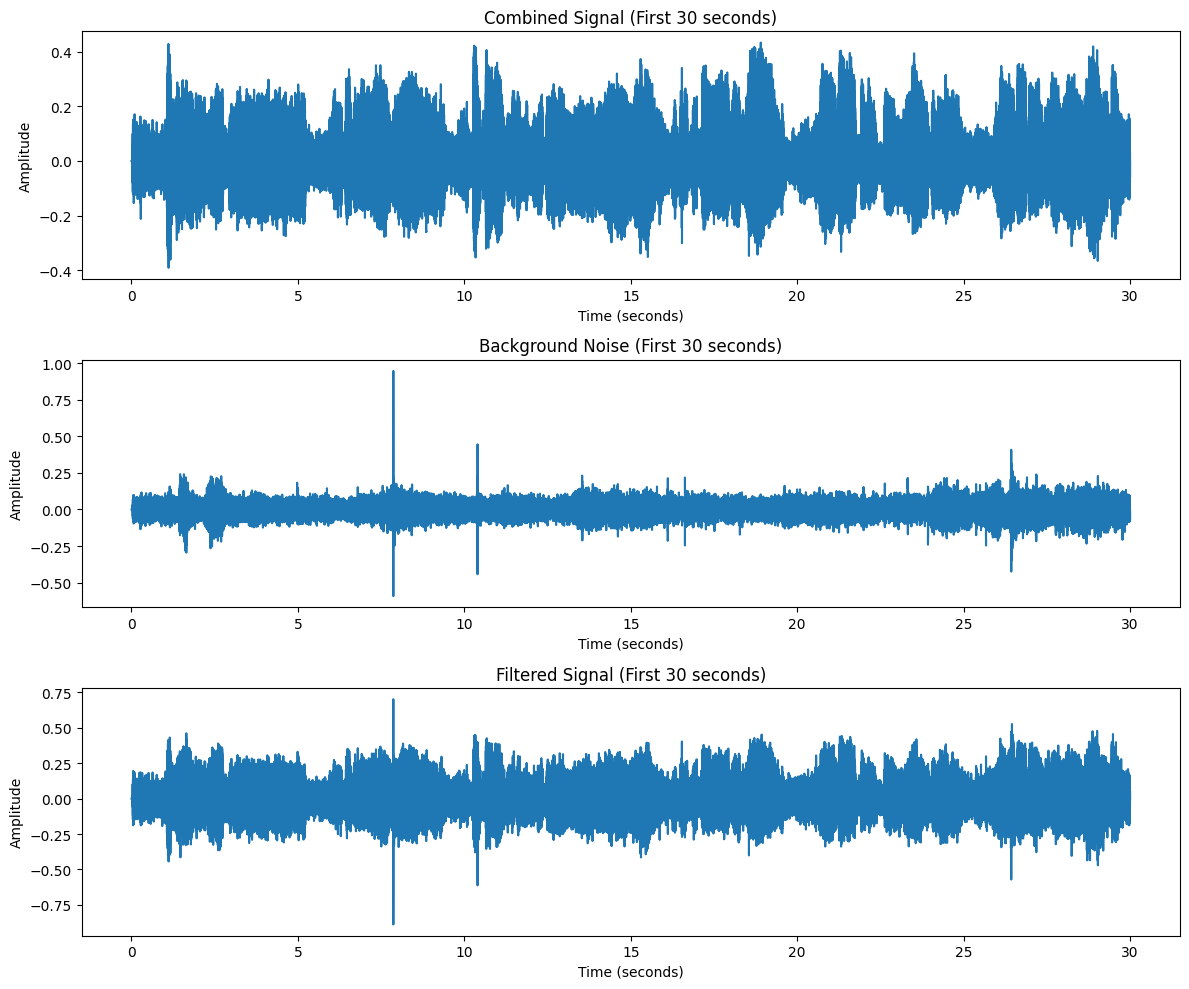

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import scipy.io.wavfile as wav
from scipy.signal import resample

# Load audio files
def load_audio(file_path):
    waveform, sr = torchaudio.load(file_path)
    return waveform.squeeze().numpy(), sr

combined_signal, sr_combined = load_audio('eemazha.wav')
background_noise, sr_noise = load_audio('noise.wav')

# Ensure the signals have the same sample rate
assert sr_combined == sr_noise, "Sample rates of combined signal and background noise do not match."

# Convert stereo to mono if necessary
def stereo_to_mono(signal):
    if signal.ndim > 1:
        return np.mean(signal, axis=0)
    return signal

combined_signal = stereo_to_mono(combined_signal)
background_noise = stereo_to_mono(background_noise)

# Ensure the background noise is the same length as the combined signal
if len(background_noise) < len(combined_signal):
    padding = len(combined_signal) - len(background_noise)
    background_noise = np.pad(background_noise, (0, padding), mode='constant')
elif len(background_noise) > len(combined_signal):
    background_noise = background_noise[:len(combined_signal)]

# Apply FFT to both signals
X_combined = np.fft.fft(combined_signal)
X_noise = np.fft.fft(background_noise)

# Ensure the noise mask is the same length as the FFT arrays
noise_threshold = 0.1
noise_mask = np.abs(X_noise) > noise_threshold

# Make sure noise_mask matches X_combined and X_noise
if len(noise_mask) != len(X_combined):
    # Adjust noise_mask length to match X_combined
    noise_mask = np.pad(noise_mask, (0, len(X_combined) - len(noise_mask)), mode='constant')

# Create filtered FFT array by subtracting noise components
X_filtered = X_combined.copy()
X_filtered[noise_mask] = X_filtered[noise_mask] - X_noise[noise_mask]

# Apply IFFT to get the filtered signal in the time domain
filtered_signal = np.fft.ifft(X_filtered).real

# Define the duration to display (30 seconds)
duration = 30
num_samples = int(duration * sr_combined)

# Create time vectors for plotting
time_combined = np.arange(len(combined_signal)) / sr_combined
time_filtered = np.arange(len(filtered_signal)) / sr_combined

# Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# Plot original combined signal
ax[0].plot(time_combined[:num_samples], combined_signal[:num_samples])
ax[0].set_title('Combined Signal (First 30 seconds)')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')

# Plot background noise
ax[1].plot(time_combined[:num_samples], background_noise[:num_samples])
ax[1].set_title('Background Noise (First 30 seconds)')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Amplitude')

# Plot filtered signal
ax[2].plot(time_filtered[:num_samples], filtered_signal[:num_samples])
ax[2].set_title('Filtered Signal (First 30 seconds)')
ax[2].set_xlabel('Time (seconds)')
ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Save the filtered signal to a new WAV file
wav.write('filtered_signal_2.wav', sr_combined, (filtered_signal * 32767).astype(np.int16))  # Scaling for 16-bit PCM
